In [1]:
from PIL import Image

import torch

import numpy as np

In [2]:
from gdino import GDINO

/home/crest/Documents/Github/PotatoScan/3dscan/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
gdino_model = GDINO()
gdino_model.build_model(device="cuda")

One or both local paths not provided. Loading from Hugging Face Hub: IDEA-Research/grounding-dino-base


In [4]:
texts_prompt = "potato tuber. colored pin"

In [5]:
image_pil = Image.open("/home/crest/w/hwang_Pro/data/202509_sarabetsu_potato/01_sfm_model/images/087/006/DSC_006_20251002_160444_5510.jpg")

In [6]:
gdino_results = gdino_model.predict([image_pil], [texts_prompt], box_threshold=0.3, text_threshold=0.25)

In [7]:
gdino_results

/home/crest/Documents/Github/PotatoScan/3dscan/.venv/lib/python3.11/site-packages/transformers/models/grounding_dino/processing_grounding_dino.py:93: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


[{'scores': tensor([0.3831, 0.3720, 0.3648], device='cuda:0'),
  'boxes': tensor([[1805.4601, 1430.6503, 3130.1958, 2868.6177],
          [2216.0107, 2110.6123, 2877.1938, 2866.9617],
          [1804.2742, 1431.8480, 3129.5999, 2222.2280]], device='cuda:0'),
  'text_labels': ['potato tuber', 'potato tuber', 'potato tuber'],
  'labels': ['potato tuber', 'potato tuber', 'potato tuber']}]

In [8]:
def merge_boxes(gdino_results):
    # Extract the tensor containing all boxes
    all_boxes = gdino_results[0]['boxes']

    # Check if there are any boxes to merge
    if all_boxes.shape[0] > 0:
        # Find the min of all x1 and y1 coordinates
        min_xy = all_boxes[:, :2].min(dim=0).values
        
        # Find the max of all x2 and y2 coordinates
        max_xy = all_boxes[:, 2:].max(dim=0).values
        
        # Concatenate to form the merged bounding box
        merged_box = torch.cat([min_xy, max_xy])
        
        print("Merged BBox:", merged_box)

        return merged_box
    else:
        print("No bounding boxes to merge.")
        return None

In [9]:
bbox = merge_boxes(gdino_results)

bbox

Merged BBox: tensor([1804.2742, 1430.6503, 3130.1958, 2868.6177], device='cuda:0')


tensor([1804.2742, 1430.6503, 3130.1958, 2868.6177], device='cuda:0')

In [10]:
bbox_array = bbox.cpu().numpy()

bbox_array

array([1804.2742, 1430.6503, 3130.1958, 2868.6177], dtype=float32)

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

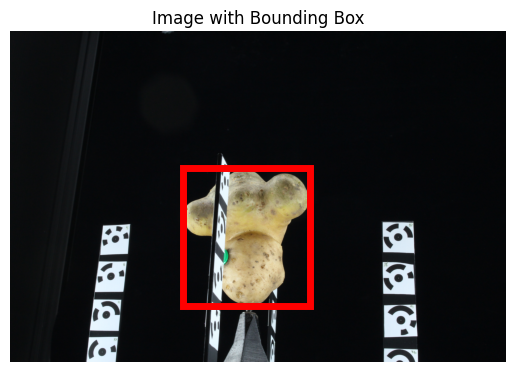

In [12]:
# Matplotlib 的 patches.Rectangle 构造函数需要 (xmin, ymin) 和 (width, height)
xmin, ymin, xmax, ymax = bbox_array
width = xmax - xmin
height = ymax - ymin

# --- 3. 使用 Matplotlib 绘制 ---

fig, ax = plt.subplots(1)

# 显示图像
ax.imshow(np.asarray(image_pil))

# 创建一个矩形 Patch
rect = patches.Rectangle(
    (xmin, ymin), # 左上角坐标 (x, y)
    width,        # 宽度
    height,       # 高度
    linewidth=5,  # 线宽
    edgecolor='r', # 边框颜色 (red)
    facecolor='none' # 不填充颜色
)

# 将矩形添加到图像上
ax.add_patch(rect)

# 隐藏坐标轴
ax.axis('off')

# 设置图表标题
ax.set_title('Image with Bounding Box')

# --- 4. 显示或保存图表 ---

# 显示图表
plt.show()

In [13]:
def predict(
        images_pil: list[Image.Image],
        texts_prompt: list[str],
        box_threshold: float = 0.3,
        text_threshold: float = 0.25,
    ):
        """Predicts masks for given images and text prompts using GDINO and SAM models.

        Parameters:
            images_pil (list[Image.Image]): List of input images.
            texts_prompt (list[str]): List of text prompts corresponding to the images.
            box_threshold (float): Threshold for box predictions.
            text_threshold (float): Threshold for text predictions.

        Returns:
            list[dict]: List of results containing masks and other outputs for each image.
            Output format:
            [{
                "boxes": np.ndarray,
                "scores": np.ndarray,
                "masks": np.ndarray,
                "mask_scores": np.ndarray,
            }, ...]
        """

        gdino_results = self.gdino.predict(images_pil, texts_prompt, box_threshold, text_threshold)
        all_results = []
        sam_images = []
        sam_boxes = []
        sam_indices = []
        for idx, result in enumerate(gdino_results):
            result = {k: (v.cpu().numpy() if hasattr(v, "numpy") else v) for k, v in result.items()}
            processed_result = {
                **result,
                "masks": [],
                "mask_scores": [],
            }

            if result["labels"]:
                sam_images.append(np.asarray(images_pil[idx]))
                sam_boxes.append(processed_result["boxes"])
                sam_indices.append(idx)

            all_results.append(processed_result)

        if sam_images:
            print(f"Predicting {len(sam_boxes)} masks")
            masks, mask_scores, _ = self.sam.predict_batch(sam_images, xyxy=sam_boxes)
            for idx, mask, score in zip(sam_indices, masks, mask_scores):
                all_results[idx].update(
                    {
                        "masks": mask,
                        "mask_scores": score,
                    }
                )
            print(f"Predicted {len(all_results)} masks")

        return all_results

interactive annotation by sam2 video tracking

In [14]:
from ultralytics.models.sam import SAM2DynamicInteractivePredictor

In [18]:
overrides = dict(conf=0.01, task="segment", mode="predict", imgsz=1024, model="checkpoints/sam_models/sam2.1_b.pt", save=False)

In [19]:
predictor = SAM2DynamicInteractivePredictor(overrides=overrides, max_obj_num=10)

In [20]:
results = predictor(source="/home/crest/w/hwang_Pro/data/202509_sarabetsu_potato/01_sfm_model/images/087/006/DSC_006_20251002_160444_5510.jpg",
          bboxes=[bbox.cpu().numpy()], obj_ids=[1], update_memory=True)


Ultralytics 8.3.204 🚀 Python-3.11.12 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3090, 24090MiB)
image 1/1 /home/crest/w/hwang_Pro/data/202509_sarabetsu_potato/01_sfm_model/images/087/006/DSC_006_20251002_160444_5510.jpg: 1024x1024 1 0, 840.5ms
Speed: 4.0ms preprocess, 840.5ms inference, 1.1ms postprocess per image at shape (1, 3, 1024, 1024)


In [21]:
results[0].save()

'results_DSC_006_20251002_160444_5510.jpg'

In [69]:
results[0]

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: ultralytics.engine.results.Masks object
names: {0: '0'}
obb: None
orig_img: array([[[19, 17, 16],
        [18, 16, 15],
        [18, 17, 13],
        ...,
        [ 8,  6,  6],
        [ 9,  7,  7],
        [ 8,  6,  6]],

       [[20, 18, 17],
        [19, 17, 16],
        [18, 17, 13],
        ...,
        [ 8,  6,  6],
        [ 9,  7,  7],
        [ 8,  6,  6]],

       [[19, 17, 16],
        [20, 18, 17],
        [19, 18, 14],
        ...,
        [ 9,  7,  7],
        [ 9,  7,  7],
        [ 9,  7,  7]],

       ...,

       [[13, 11, 10],
        [12, 10,  9],
        [12, 10,  9],
        ...,
        [ 9,  9,  9],
        [ 8,  8,  8],
        [ 5,  5,  5]],

       [[13, 11, 10],
        [12, 10,  9],
        [12, 10,  9],
        ...,
        [ 8,  8,  8],
        [ 7,  7,  7],
        [ 6,  6,  6]],

       [[12, 10,  9],
        [11,  9,  8],
  

In [62]:
results[0].masks.data.shape

torch.Size([1, 3456, 5184])

On the next image

In [22]:
results = predictor(source="/home/crest/w/hwang_Pro/data/202509_sarabetsu_potato/01_sfm_model/images/087/006/DSC_006_20251002_160445_5511.jpg")


image 1/1 /home/crest/w/hwang_Pro/data/202509_sarabetsu_potato/01_sfm_model/images/087/006/DSC_006_20251002_160445_5511.jpg: 1024x1024 1 0, 128.4ms
Speed: 8.0ms preprocess, 128.4ms inference, 0.9ms postprocess per image at shape (1, 3, 1024, 1024)


In [23]:
results[0]

ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
keypoints: None
masks: ultralytics.engine.results.Masks object
names: {0: '0'}
obb: None
orig_img: array([[[19, 18, 14],
        [16, 15, 11],
        [16, 15, 11],
        ...,
        [ 7,  5,  4],
        [ 6,  4,  3],
        [ 7,  5,  4]],

       [[20, 19, 15],
        [18, 17, 13],
        [17, 16, 12],
        ...,
        [ 7,  5,  4],
        [ 7,  5,  4],
        [ 8,  6,  5]],

       [[18, 17, 13],
        [18, 17, 13],
        [18, 17, 13],
        ...,
        [ 7,  5,  4],
        [ 8,  6,  5],
        [ 9,  7,  6]],

       ...,

       [[13, 11, 11],
        [13, 11, 11],
        [12, 10, 10],
        ...,
        [ 7,  5,  4],
        [ 7,  5,  4],
        [ 7,  5,  4]],

       [[13, 11, 11],
        [13, 11, 11],
        [11,  9,  9],
        ...,
        [ 7,  5,  4],
        [ 6,  4,  3],
        [ 6,  4,  3]],

       [[13, 11, 10],
        [14, 12, 11],
  

In [24]:
results[0].save()

'results_DSC_006_20251002_160445_5511.jpg'